         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

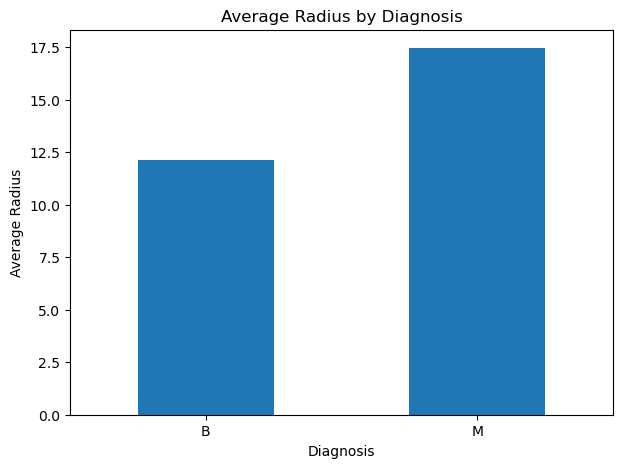

<Figure size 700x500 with 0 Axes>

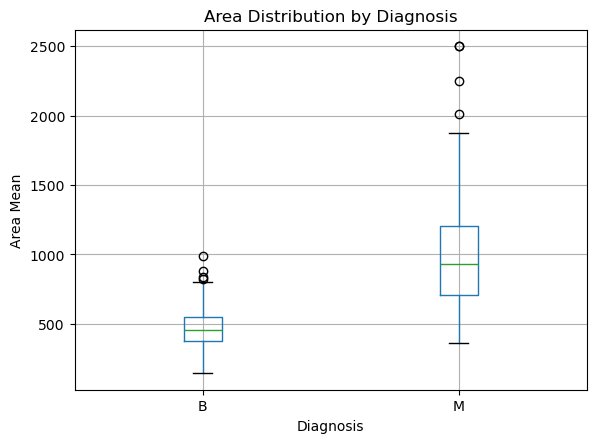

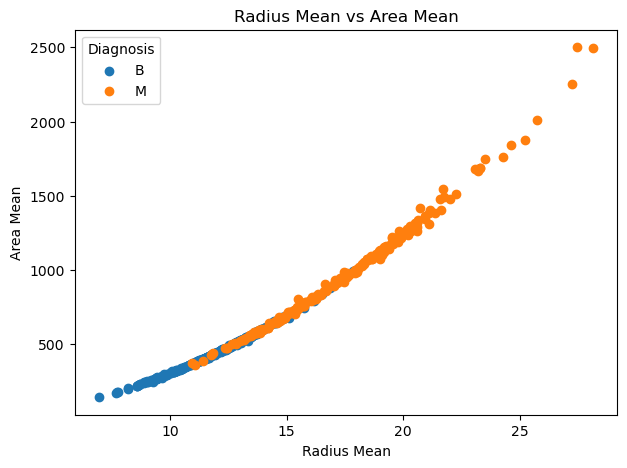

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Import the downloaded CSV dataset
df = pd.read_csv(r"C:\Users\Anusri\Downloads\breast-cancer.csv")

# Remove unnecessary empty column if it exists
if "Unnamed: 32" in df.columns:
    df = df.drop("Unnamed: 32", axis=1)

# Display first 5 records
print(df.head())

# Display dimensions
print("\nShape of Dataset:")
print(df.shape)

# Display data types
print("\nData Types:")
print(df.dtypes)

# Filter malignant cases
malignant = df[df["diagnosis"] == "M"]
print("\nMalignant Cases:")
print(malignant.head())

# Filter cases where mean radius is greater than 15
high_radius = df[df["radius_mean"] > 15]
print("\nCases with Radius Mean > 15:")
print(high_radius.head())

# Sort dataset based on area_mean
sorted_df = df.sort_values(by="area_mean", ascending=False)
print("\nSorted Data:")
print(sorted_df[["id", "diagnosis", "radius_mean", "area_mean"]].head())

# Statistical analysis
print("\nMean:")
print(df["radius_mean"].mean())

print("\nMedian:")
print(df["radius_mean"].median())

print("\nMode:")
print(df["radius_mean"].mode())

print("\nStandard Deviation:")
print(df["radius_mean"].std())

# Statistical summary
print("\nStatistical Summary:")
print(df[["radius_mean", "area_mean", "perimeter_mean"]].describe())

# Grouping and aggregation
print("\nAverage Radius by Diagnosis:")
print(df.groupby("diagnosis")["radius_mean"].mean())

# Correlation
print("\nCorrelation:")
corr = df[["radius_mean", "area_mean"]].corr()
print(corr)

# Bar Chart
plt.figure(figsize=(7, 5))
df.groupby("diagnosis")["radius_mean"].mean().plot(kind="bar")
plt.title("Average Radius by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Average Radius")
plt.xticks(rotation=0)
plt.show()

# Box Plot
plt.figure(figsize=(7, 5))
df.boxplot(column="area_mean", by="diagnosis")
plt.title("Area Distribution by Diagnosis")
plt.suptitle("")
plt.xlabel("Diagnosis")
plt.ylabel("Area Mean")
plt.show()

# Scatter Plot
plt.figure(figsize=(7, 5))
for diagnosis in ["B", "M"]:
    subset = df[df["diagnosis"] == diagnosis]
    plt.scatter(
        subset["radius_mean"],
        subset["area_mean"],
        label=diagnosis
    )

plt.title("Radius Mean vs Area Mean")
plt.xlabel("Radius Mean")
plt.ylabel("Area Mean")
plt.legend(title="Diagnosis")
plt.show()